In [2]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 5]

In [4]:
# Caminho apontando para a pasta que você mostrou na imagem
dataset_path = Path("archive")

# Extensões de imagem comuns
valid_extensions = {".jpg", ".jpeg", ".png", ".bmp"}

data = []

# Varre todos os arquivos dentro da pasta archive
for file_path in dataset_path.rglob("*"):
    if file_path.suffix.lower() in valid_extensions:
        # Captura o caminho relativo a partir de 'archive'
        relative_parts = file_path.relative_to(dataset_path).parts
        
        # Se tiver estrutura: archive/train/nome_da_classe/imagem.jpg
        if len(relative_parts) >= 3:
            split = relative_parts[0]  # train, val, test
            label = relative_parts[1]  # nome da doença/saudável
        # Se tiver estrutura direta: archive/nome_da_classe/imagem.jpg
        else:
            split = "Geral"
            label = relative_parts[0]
            
        data.append({"Split": split, "Classe": label})

# Criar o DataFrame principal
df_images = pd.DataFrame(data)

if df_images.empty:
    print("Pasta Archive errada.")
else:
    print(f"Total de imagens encontradas: {len(df_images)}")

Total de imagens encontradas: 1167


In [7]:
# Agrupa por classe e split (se houver) para contar
if df_images['Split'].nunique() > 1:
    df_dist = df_images.groupby(['Split', 'Classe']).size().reset_index(name='Quantidade')
    df_dist['Porcentagem (%)'] = (df_dist['Quantidade'] / df_dist.groupby('Split')['Quantidade'].transform('sum')) * 100
else:
    df_dist = df_images.groupby('Classe').size().reset_index(name='Quantidade')
    df_dist['Porcentagem (%)'] = (df_dist['Quantidade'] / df_dist['Quantidade'].sum()) * 100

# Exibir a tabela formatada
print("\n         Tabela de Distribuição de Classes")
print(df_dist.to_string(index=False, formatters={'Porcentagem (%)': '{:.2f}%'.format}))


         Tabela de Distribuição de Classes
Split            Classe  Quantidade Porcentagem (%)
train angular_leaf_spot         345          33.37%
train         bean_rust         348          33.66%
train           healthy         341          32.98%
  val angular_leaf_spot          44          33.08%
  val         bean_rust          45          33.83%
  val           healthy          44          33.08%


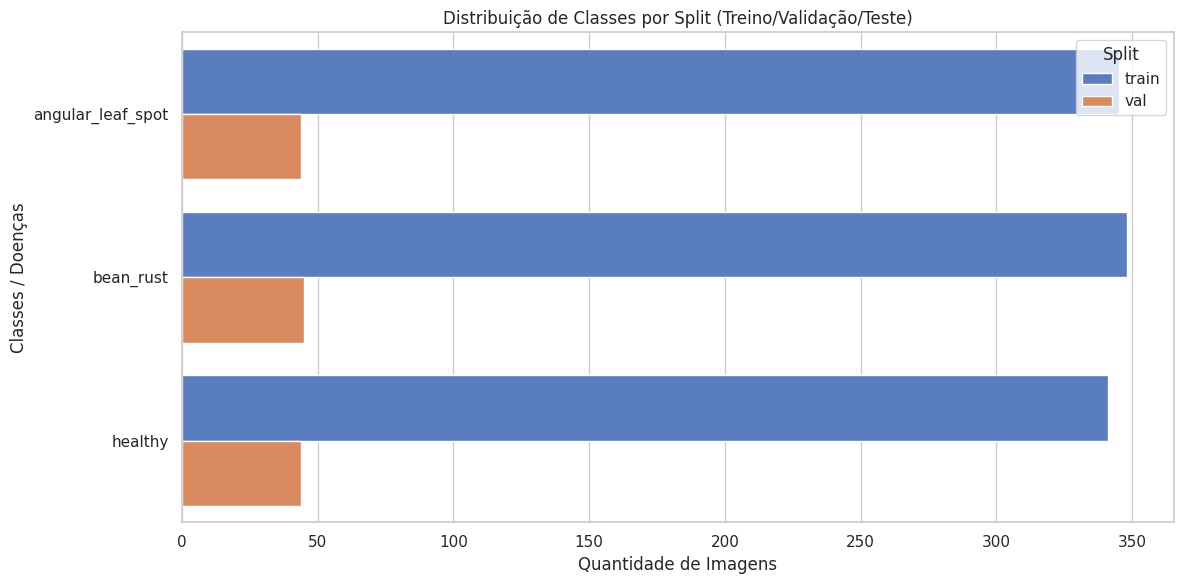

In [8]:
# Plotar o gráfico dependendo da estrutura encontrada
plt.figure(figsize=(12, 6))

if df_images['Split'].nunique() > 1:
    # Gráfico comparativo se houver divisões de treino/validação
    sns.barplot(x='Quantidade', y='Classe', hue='Split', data=df_dist, palette='muted')
    plt.title('Distribuição de Classes por Split (Treino/Validação/Teste)')
else:
    # Gráfico simples
    sns.barplot(x='Quantidade', y='Classe', data=df_dist.sort_values('Quantidade', ascending=False), palette='viridis')
    plt.title('Distribuição Geral de Classes - Lesões de Folhas de Feijão')

plt.xlabel('Quantidade de Imagens')
plt.ylabel('Classes / Doenças')
plt.tight_layout()
plt.show()

## Insights 

- As três classes (angular_leaf_spot, bean_rust e healthy) estão distribuídas de forma praticamente idêntica, representando exatamente ~33.3% do dataset cada uma. Não é preciso se preocupar com o balanceamento de dados, o modelo tem a quantidade de exemplos necessária para saber o que é uma folha saudável e o que é cada tipo de doença.

-  A Acurácia nesse projeto vai ser uma métrica extremamente confiável devido a natureza balanceada apresentada nesse dataset.

-  Existe um total de 1.034 imagens de treino e 133 imagens de validação (uma proporção de aproximadamente 88.5% / 11.5%).